# 02 · Análisis Exploratorio de Datos (EDA)
### Predicción de Riesgo de Incumplimiento Crediticio · Dataset UCI

---
> **Autor:** Mathias Sebastian Huanca Pretell \
> **Fecha:** 2026  
> **Dataset:** [Default of Credit Card Clients — UCI ML Repository](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)  
> **Notebook:** `02_EDA.ipynb`  
> **Estado:** ✅ Completo

---

**Hoja de ruta del proyecto**

| # | Notebook | Estado |
|---|----------|--------|
| 01 | Entendimiento del Negocio | ✅ Completo |
| 02 | Análisis Exploratorio de Datos (EDA) | ✅ Actual |
| 03 | Preprocesamiento | 🔜 |
| 04 | Feature Engineering | 🔜 |
| 05 | Modelado y Evaluación | 🔜 |
| 06 | Conclusiones y Recomendaciones de Negocio | 🔜 |

## Tabla de Contenidos

1. [Objetivo del EDA](#1-objetivo-del-eda)
2. [Configuración del Entorno](#2-configuración-del-entorno)
3. [Carga y Primera Vista del Dataset](#3-carga-y-primera-vista-del-dataset)
4. [Calidad de Datos](#4-calidad-de-datos)
   - 4.1 Valores nulos
   - 4.2 Duplicados
   - 4.3 Categorías no documentadas
5. [Análisis de la Variable Target](#5-análisis-de-la-variable-target)
6. [Análisis Univariado](#6-análisis-univariado)
   - 6.1 Variables demográficas
   - 6.2 Variables financieras
   - 6.3 Variables de historial de pagos
7. [Análisis Bivariado — Variables vs Target](#7-análisis-bivariado--variables-vs-target)
   - 7.1 Variables demográficas vs Target
   - 7.2 Variables financieras vs Target
   - 7.3 Historial de pagos vs Target
8. [Detección de Outliers](#8-detección-de-outliers)
9. [Análisis de Correlaciones](#9-análisis-de-correlaciones)
10. [Validación de Hipótesis](#10-validación-de-hipótesis)
11. [Resumen de Hallazgos](#11-resumen-de-hallazgos)

---
## 1. Objetivo del EDA

El objetivo de este notebook es explorar el dataset de manera sistemática para:

- **Validar la calidad de los datos:** Detectar nulos, duplicados y categorías inconsistentes.
- **Entender las distribuciones:** Identificar asimetrías, concentraciones y valores extremos en cada variable.
- **Descubrir relaciones con el target:** Determinar qué variables tienen mayor poder discriminatorio entre clientes que hacen default y los que no.
- **Detectar outliers:** Evaluar su origen y decidir el tratamiento adecuado en la fase de preprocesamiento.
- **Validar las hipótesis planteadas** en el notebook de Business Understanding.

> Todos los hallazgos de este notebook alimentan directamente las decisiones de preprocesamiento y feature engineering en los notebooks siguientes.

---
## 2. Configuración del Entorno

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
import jinja2

warnings.filterwarnings('ignore')

# Estilo de gráficos
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

# Colores para target (0=azul, 1=rojo)
TARGET_PALETTE = {0: '#4C72B0', 1: '#DD4444'}
TARGET_LABELS  = {0: 'Sin Default', 1: 'Default'}

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 3. Carga y Primera Vista del Dataset

In [2]:
# Carga del dataset (el XLS original tiene una fila de título extra, header=1 la omite)
df = pd.read_excel('../data/raw/default of credit card clients.xls', header=1)

# Renombrar columna target para facilitar el uso
df.rename(columns={'default payment next month': 'TARGET'}, inplace=True)

print(f'Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head(5)

Dimensiones: 30,000 filas × 25 columnas


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,TARGET
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
# Tipos de datos y conteo de no-nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   30000 non-nu

In [6]:
# Estadísticas descriptivas generales
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std', 'min', 'max'])

,count,mean,std,min,25%,50%,75%,max
ID,30000.000000,15000.500000,8660.398374,1.000000,7500.750000,15000.500000,22500.250000,30000.000000
LIMIT_BAL,30000.000000,167484.322667,129747.661567,10000.000000,50000.000000,140000.000000,240000.000000,1000000.000000
SEX,30000.000000,1.603733,0.489129,1.000000,1.000000,2.000000,2.000000,2.000000
EDUCATION,30000.000000,1.853133,0.790349,0.000000,1.000000,2.000000,2.000000,6.000000
MARRIAGE,30000.000000,1.551867,0.521970,0.000000,1.000000,2.000000,2.000000,3.000000
AGE,30000.000000,35.485500,9.217904,21.000000,28.000000,34.000000,41.000000,79.000000
PAY_0,30000.000000,-0.016700,1.123802,-2.000000,-1.000000,0.000000,0.000000,8.000000
PAY_2,30000.000000,-0.133767,1.197186,-2.000000,-1.000000,0.000000,0.000000,8.000000
PAY_3,30000.000000,-0.166200,1.196868,-2.000000,-1.000000,0.000000,0.000000,8.000000
PAY_4,30000.000000,-0.220667,1.169139,-2.000000,-1.000000,0.000000,0.000000,8.000000


---
## 4. Calidad de Datos

### 4.1 Valores Nulos

In [7]:
null_df = pd.DataFrame({
    'Nulos': df.isnull().sum(),
    '% del Total': (df.isnull().sum() / len(df) * 100).round(2)
})
null_df = null_df[null_df['Nulos'] > 0]

if null_df.empty:
    print('✅ No se encontraron valores nulos en el dataset.')
else:
    print(f'⚠️ Se encontraron valores nulos en {len(null_df)} columnas:')
    display(null_df)

✅ No se encontraron valores nulos en el dataset.


### 4.2 Filas Duplicadas

In [8]:
n_dup = df.duplicated().sum()
# La columna ID no debe ser única obligatoriamente en este dataset
n_dup_no_id = df.drop(columns='ID').duplicated().sum()

print(f'Filas completamente duplicadas (incl. ID): {n_dup}')
print(f'Filas duplicadas excluyendo ID:            {n_dup_no_id}')

if n_dup_no_id > 0:
    print('⚠️ Existen filas con mismos valores en todas las variables excepto ID. Revisar en preprocesamiento.')
else:
    print('✅ No se encontraron filas duplicadas relevantes.')

Filas completamente duplicadas (incl. ID): 0
Filas duplicadas excluyendo ID:            35
⚠️ Existen filas con mismos valores en todas las variables excepto ID. Revisar en preprocesamiento.


### 4.3 Categorías No Documentadas

Según lo identificado en el Business Understanding, las variables `EDUCATION`, `MARRIAGE` y `PAY_X` contienen categorías que no están documentadas en el paper original. Se investigan a continuación.

In [9]:
# EDUCATION: documentado 1-4, categorías 5 y 6 son desconocidas
print('=== EDUCATION ===')
edu_counts = df['EDUCATION'].value_counts().sort_index()
print(edu_counts.to_string())
undoc_edu = df['EDUCATION'].isin([0, 5, 6]).sum()
print(f'\nRegistros con categorías no documentadas (0, 5, 6): {undoc_edu} ({undoc_edu/len(df)*100:.2f}%)')

print('\n=== MARRIAGE ===')
mar_counts = df['MARRIAGE'].value_counts().sort_index()
print(mar_counts.to_string())
undoc_mar = df['MARRIAGE'].isin([0]).sum()
print(f'\nRegistros con categoría no documentada (0): {undoc_mar} ({undoc_mar/len(df)*100:.2f}%)')

print('\n=== PAY_0 (valores únicos) ===')
print(sorted(df['PAY_0'].unique()))

=== EDUCATION ===
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51

Registros con categorías no documentadas (0, 5, 6): 345 (1.15%)

=== MARRIAGE ===
MARRIAGE
0       54
1    13659
2    15964
3      323

Registros con categoría no documentada (0): 54 (0.18%)

=== PAY_0 (valores únicos) ===
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


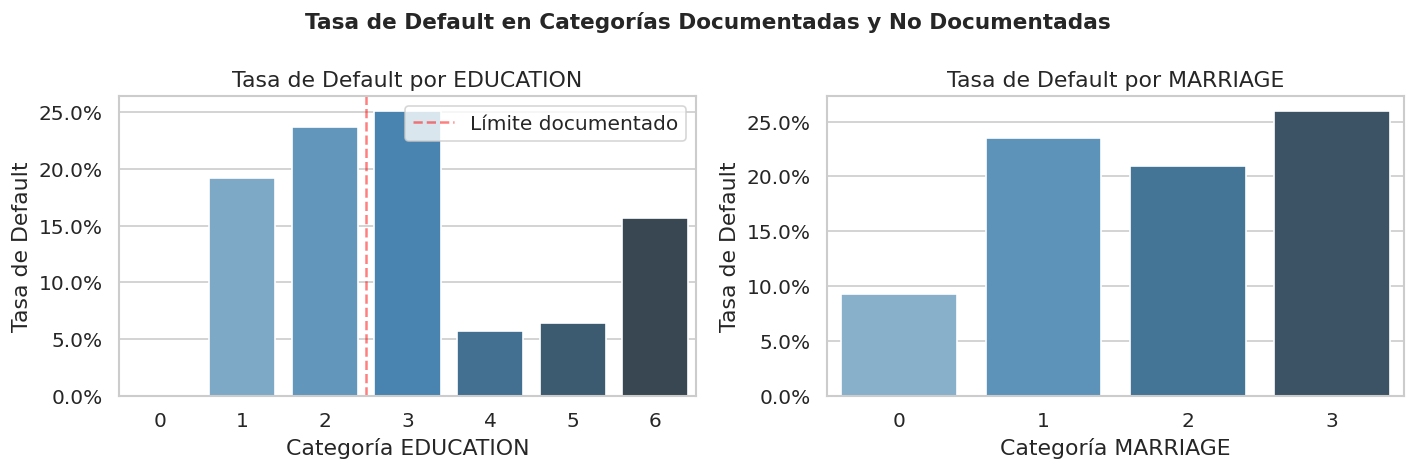


💡 Decisión de tratamiento: las categorías no documentadas (EDUCATION 0/5/6 y MARRIAGE 0)
   serán agrupadas bajo una categoría "Otros" en el notebook de Preprocesamiento.


In [10]:
# Tasa de default de las categorías no documentadas vs documentadas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# EDUCATION
edu_default = df.groupby('EDUCATION')['TARGET'].mean().reset_index()
edu_default.columns = ['EDUCATION', 'Tasa de Default']
sns.barplot(data=edu_default, x='EDUCATION', y='Tasa de Default', ax=axes[0], palette='Blues_d')
axes[0].set_title('Tasa de Default por EDUCATION')
axes[0].set_xlabel('Categoría EDUCATION')
axes[0].set_ylabel('Tasa de Default')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].axvline(x=2.5, color='red', linestyle='--', alpha=0.5, label='Límite documentado')
axes[0].legend()

# MARRIAGE
mar_default = df.groupby('MARRIAGE')['TARGET'].mean().reset_index()
mar_default.columns = ['MARRIAGE', 'Tasa de Default']
sns.barplot(data=mar_default, x='MARRIAGE', y='Tasa de Default', ax=axes[1], palette='Blues_d')
axes[1].set_title('Tasa de Default por MARRIAGE')
axes[1].set_xlabel('Categoría MARRIAGE')
axes[1].set_ylabel('Tasa de Default')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('Tasa de Default en Categorías Documentadas y No Documentadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Decisión de tratamiento: las categorías no documentadas (EDUCATION 0/5/6 y MARRIAGE 0)')
print('   serán agrupadas bajo una categoría "Otros" en el notebook de Preprocesamiento.')

---
## 5. Análisis de la Variable Target

El primer paso en cualquier problema de clasificación es entender el balance de clases, ya que determina directamente la estrategia de modelado.

Distribución de la variable target:
  Sin Default (0): 23,364 clientes (77.9%)
  Default     (1): 6,636 clientes (22.1%)
  Ratio de desbalance: 3.5:1


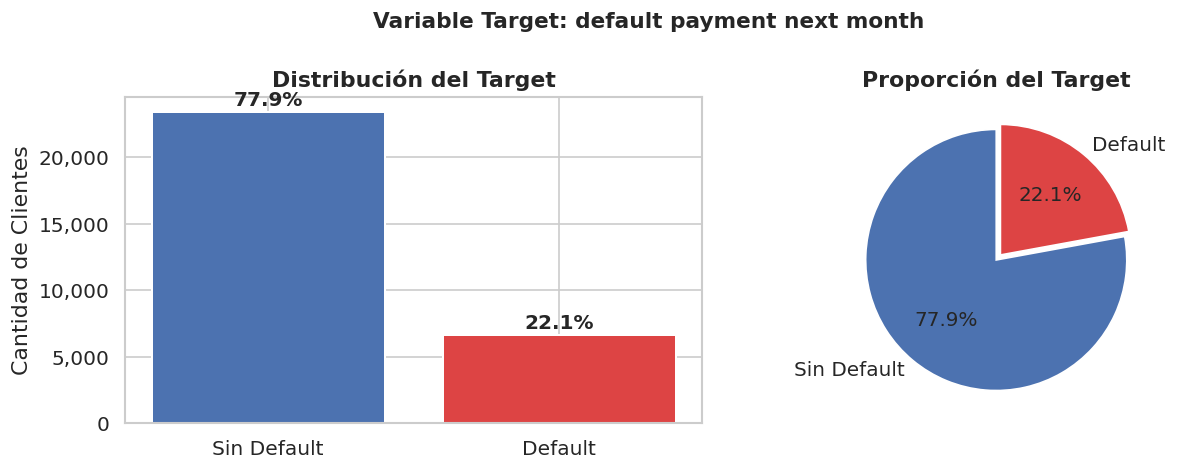


⚠️  Dataset desbalanceado: ~3.5 clientes sin default por cada cliente con default.
   Implicancia: se usarán métricas de Recall, F1 y ROC-AUC como principales.
   Estrategia: evaluar SMOTE / class_weight en la fase de modelado.


In [11]:
target_counts = df['TARGET'].value_counts()
target_pct    = df['TARGET'].value_counts(normalize=True)

print('Distribución de la variable target:')
print(f'  Sin Default (0): {target_counts[0]:,} clientes ({target_pct[0]:.1%})')
print(f'  Default     (1): {target_counts[1]:,} clientes ({target_pct[1]:.1%})')
print(f'  Ratio de desbalance: {target_counts[0]/target_counts[1]:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Barplot
bars = axes[0].bar(
    ['Sin Default', 'Default'],
    target_counts.values,
    color=[TARGET_PALETTE[0], TARGET_PALETTE[1]],
    edgecolor='white', linewidth=1.2
)
for bar, pct in zip(bars, target_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{pct:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Distribución del Target', fontweight='bold')
axes[0].set_ylabel('Cantidad de Clientes')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
axes[1].pie(
    target_counts.values,
    labels=['Sin Default', 'Default'],
    colors=[TARGET_PALETTE[0], TARGET_PALETTE[1]],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.05),
    textprops={'fontsize': 12}
)
axes[1].set_title('Proporción del Target', fontweight='bold')

plt.suptitle('Variable Target: default payment next month', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n⚠️  Dataset desbalanceado: ~3.5 clientes sin default por cada cliente con default.')
print('   Implicancia: se usarán métricas de Recall, F1 y ROC-AUC como principales.')
print('   Estrategia: evaluar SMOTE / class_weight en la fase de modelado.')

---
## 6. Análisis Univariado

Se analiza la distribución de cada variable de forma independiente para detectar asimetrías, concentraciones y valores inusuales.

### 6.1 Variables Demográficas

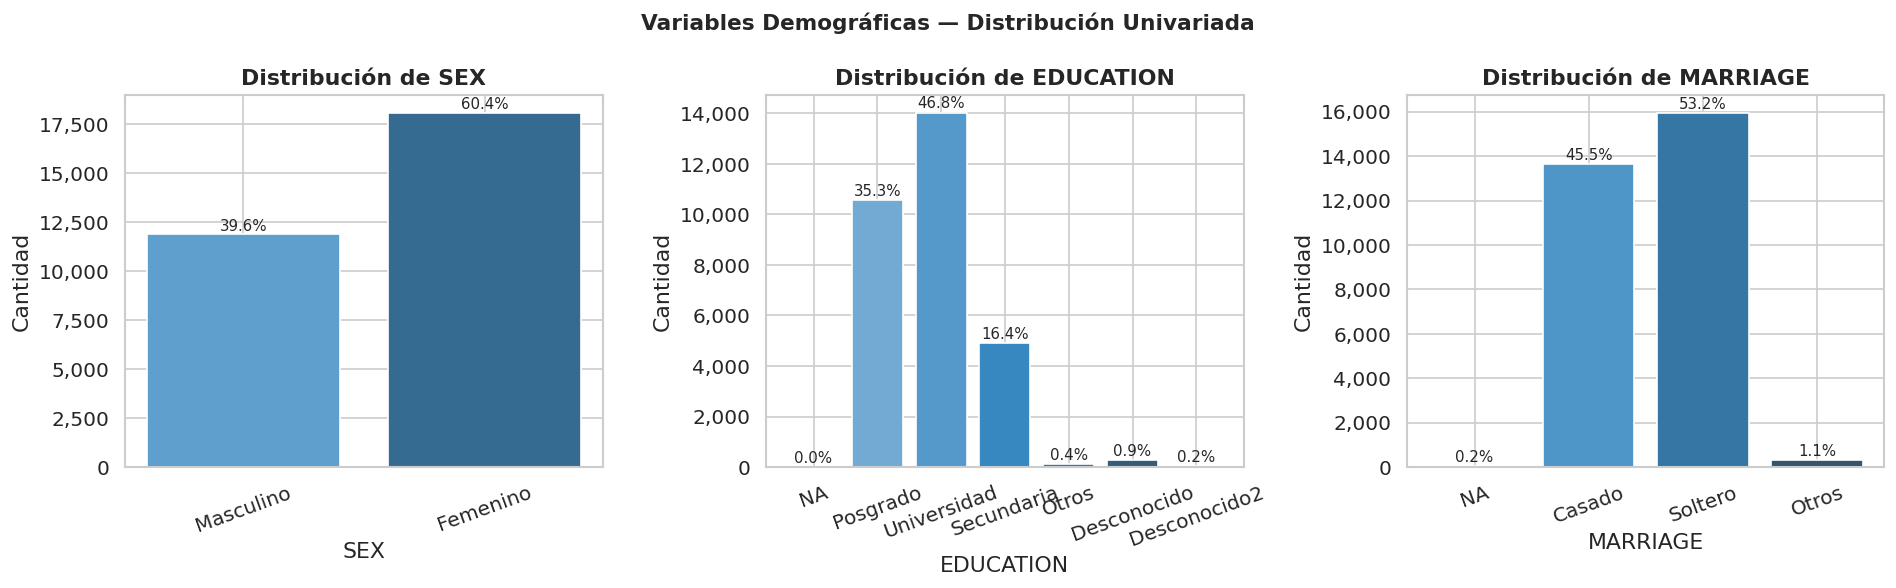

In [12]:
demo_cat_vars = {
    'SEX':       {1: 'Masculino', 2: 'Femenino'},
    'EDUCATION': {1: 'Posgrado', 2: 'Universidad', 3: 'Secundaria', 4: 'Otros', 5: 'Desconocido', 6: 'Desconocido2', 0: 'NA'},
    'MARRIAGE':  {1: 'Casado', 2: 'Soltero', 3: 'Otros', 0: 'NA'}
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, labels) in zip(axes, demo_cat_vars.items()):
    counts = df[col].value_counts().sort_index()
    x_labels = [labels.get(k, str(k)) for k in counts.index]
    bars = ax.bar(x_labels, counts.values, color=sns.color_palette('Blues_d', len(counts)), edgecolor='white')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{v/len(df)*100:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Cantidad')
    ax.tick_params(axis='x', rotation=20)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Variables Demográficas — Distribución Univariada', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

AGE — Media: 35.5 | Mediana: 34 | Min: 21 | Max: 79 | Std: 9.2


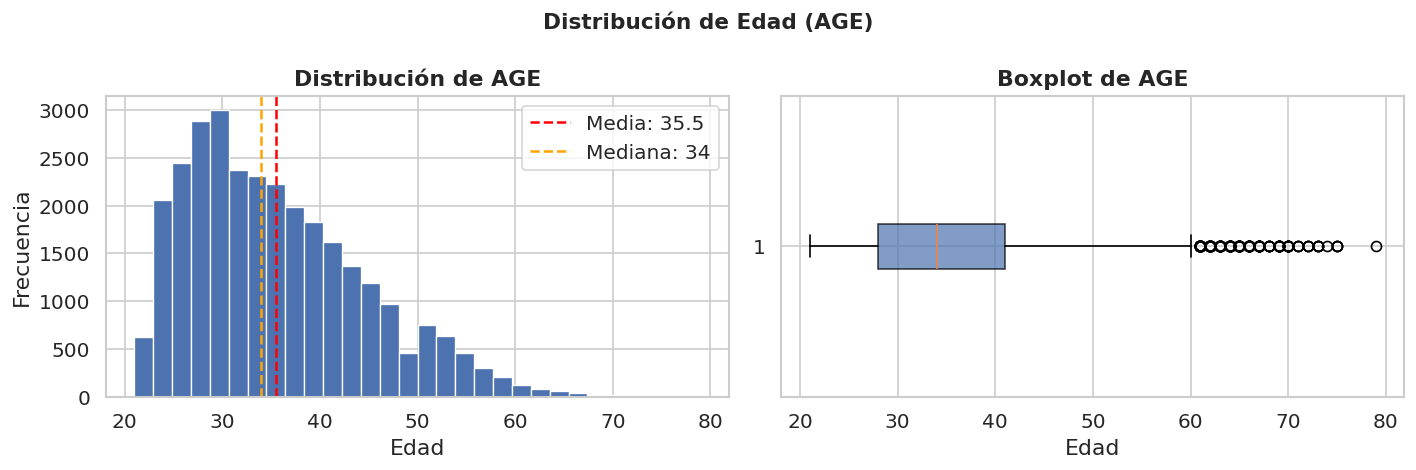

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['AGE'], bins=30, color='#4C72B0', edgecolor='white', linewidth=0.8)
axes[0].axvline(df['AGE'].mean(),   color='red',    linestyle='--', label=f"Media: {df['AGE'].mean():.1f}")
axes[0].axvline(df['AGE'].median(), color='orange', linestyle='--', label=f"Mediana: {df['AGE'].median():.0f}")
axes[0].set_title('Distribución de AGE', fontweight='bold')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

axes[1].boxplot(df['AGE'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.7))
axes[1].set_title('Boxplot de AGE', fontweight='bold')
axes[1].set_xlabel('Edad')

print(f"AGE — Media: {df['AGE'].mean():.1f} | Mediana: {df['AGE'].median():.0f} | "
      f"Min: {df['AGE'].min()} | Max: {df['AGE'].max()} | Std: {df['AGE'].std():.1f}")

plt.suptitle('Distribución de Edad (AGE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Variables Financieras

LIMIT_BAL — Media: 167,484 | Mediana: 140,000 | Min: 10,000 | Max: 1,000,000


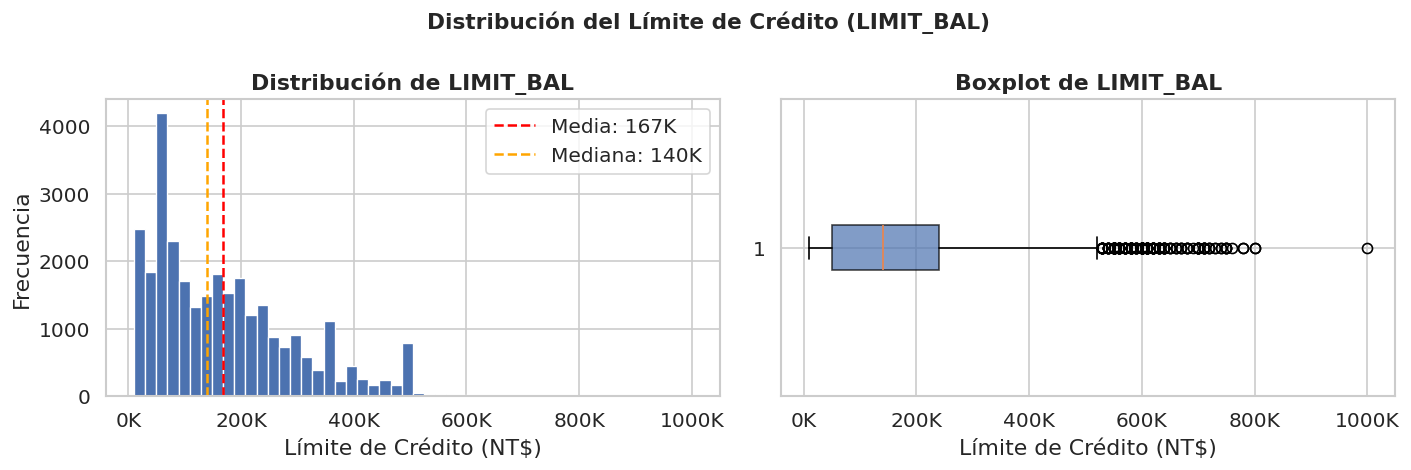

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['LIMIT_BAL'], bins=50, color='#4C72B0', edgecolor='white', linewidth=0.8)
axes[0].axvline(df['LIMIT_BAL'].mean(),   color='red',    linestyle='--', label=f"Media: {df['LIMIT_BAL'].mean()/1000:.0f}K")
axes[0].axvline(df['LIMIT_BAL'].median(), color='orange', linestyle='--', label=f"Mediana: {df['LIMIT_BAL'].median()/1000:.0f}K")
axes[0].set_title('Distribución de LIMIT_BAL', fontweight='bold')
axes[0].set_xlabel('Límite de Crédito (NT$)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

axes[1].boxplot(df['LIMIT_BAL'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.7))
axes[1].set_title('Boxplot de LIMIT_BAL', fontweight='bold')
axes[1].set_xlabel('Límite de Crédito (NT$)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

print(f"LIMIT_BAL — Media: {df['LIMIT_BAL'].mean():,.0f} | Mediana: {df['LIMIT_BAL'].median():,.0f} | "
      f"Min: {df['LIMIT_BAL'].min():,} | Max: {df['LIMIT_BAL'].max():,}")

plt.suptitle('Distribución del Límite de Crédito (LIMIT_BAL)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

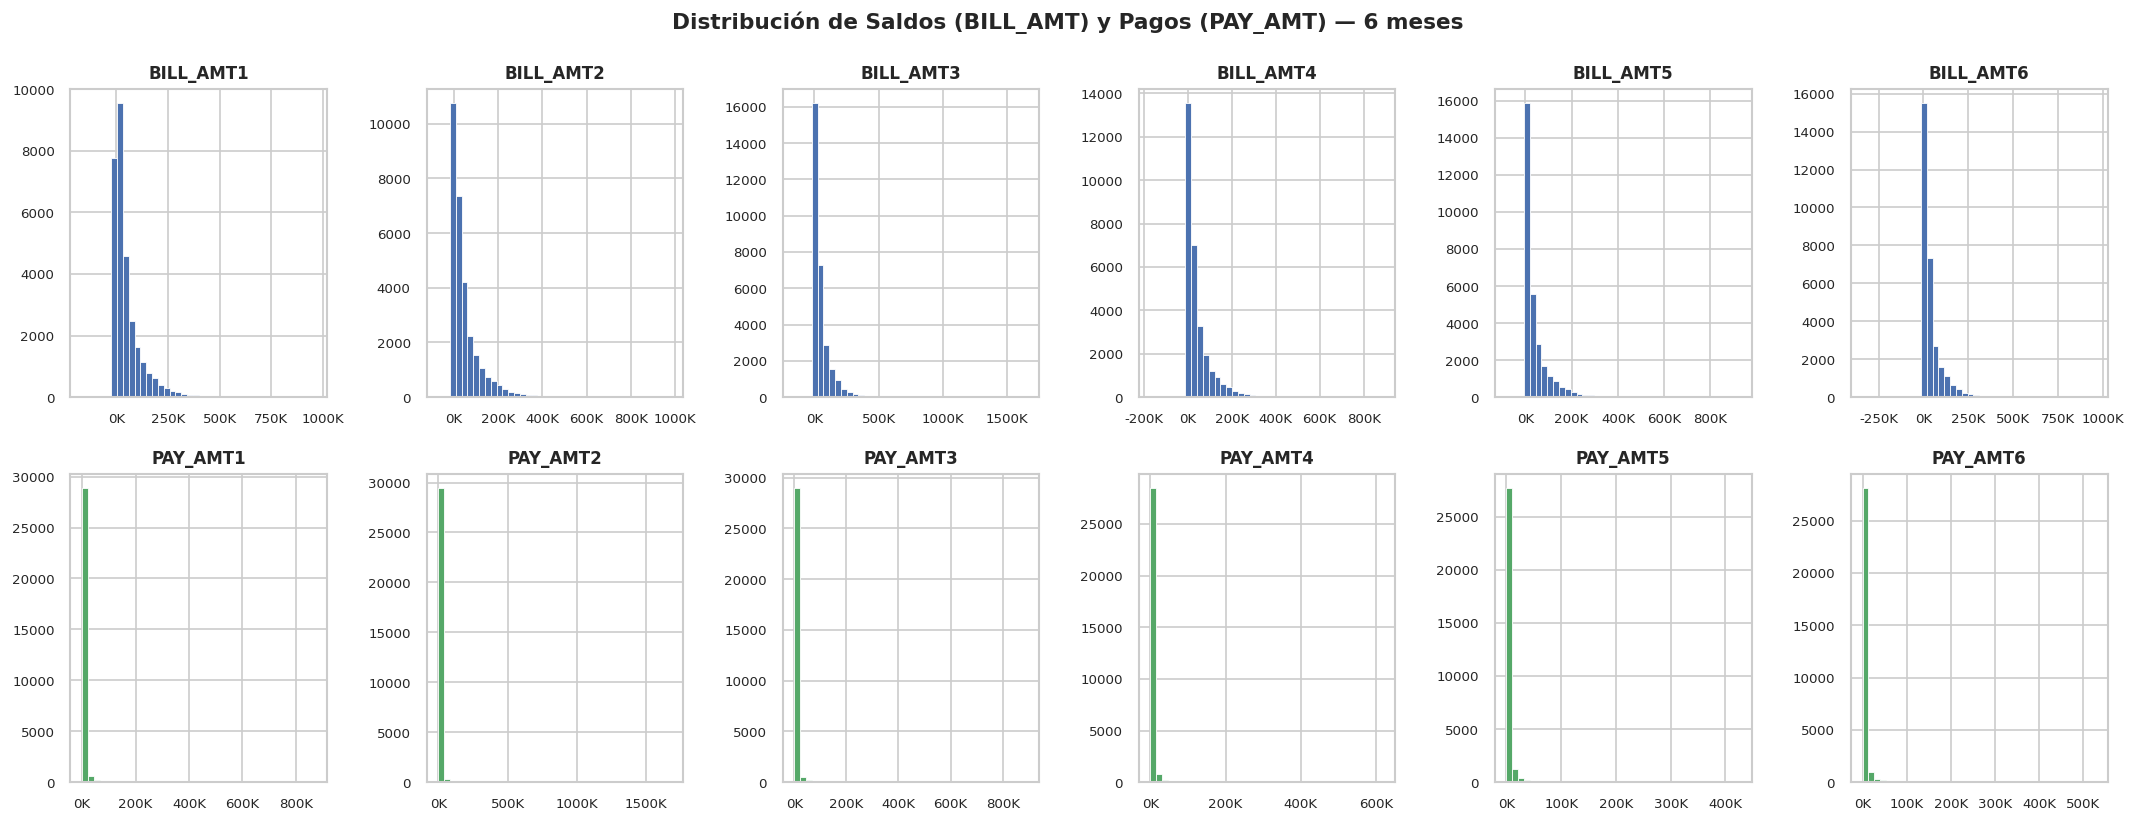

Estadísticas BILL_AMT (saldo mensual):


,mean,std,min,50%,max
BILL_AMT1,"51,223","73,636","-165,580","22,382","964,511"
BILL_AMT2,"49,179","71,174","-69,777","21,200","983,931"
BILL_AMT3,"47,013","69,349","-157,264","20,088","1,664,089"
BILL_AMT4,"43,263","64,333","-170,000","19,052","891,586"
BILL_AMT5,"40,311","60,797","-81,334","18,104","927,171"
BILL_AMT6,"38,872","59,554","-339,603","17,071","961,664"



Estadísticas PAY_AMT (pago mensual):


,mean,std,min,50%,max
PAY_AMT1,"5,664","16,563",0,"2,100","873,552"
PAY_AMT2,"5,921","23,041",0,"2,009","1,684,259"
PAY_AMT3,"5,226","17,607",0,"1,800","896,040"
PAY_AMT4,"4,826","15,666",0,"1,500","621,000"
PAY_AMT5,"4,799","15,278",0,"1,500","426,529"
PAY_AMT6,"5,216","17,777",0,"1,500","528,666"


In [15]:
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
pay_cols  = [f'PAY_AMT{i}'  for i in range(1, 7)]

fig, axes = plt.subplots(2, 6, figsize=(18, 7))

for i, col in enumerate(bill_cols):
    axes[0, i].hist(df[col], bins=40, color='#4C72B0', edgecolor='white', linewidth=0.5)
    axes[0, i].set_title(col, fontsize=10, fontweight='bold')
    axes[0, i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    axes[0, i].tick_params(labelsize=8)

for i, col in enumerate(pay_cols):
    axes[1, i].hist(df[col], bins=40, color='#55A868', edgecolor='white', linewidth=0.5)
    axes[1, i].set_title(col, fontsize=10, fontweight='bold')
    axes[1, i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    axes[1, i].tick_params(labelsize=8)

plt.suptitle('Distribución de Saldos (BILL_AMT) y Pagos (PAY_AMT) — 6 meses', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Estadísticas BILL_AMT (saldo mensual):')
display(df[bill_cols].describe().T[['mean','std','min','50%','max']].style.format('{:,.0f}'))

print('\nEstadísticas PAY_AMT (pago mensual):')
display(df[pay_cols].describe().T[['mean','std','min','50%','max']].style.format('{:,.0f}'))

### 6.3 Variables de Historial de Pagos (PAY_0 a PAY_6)

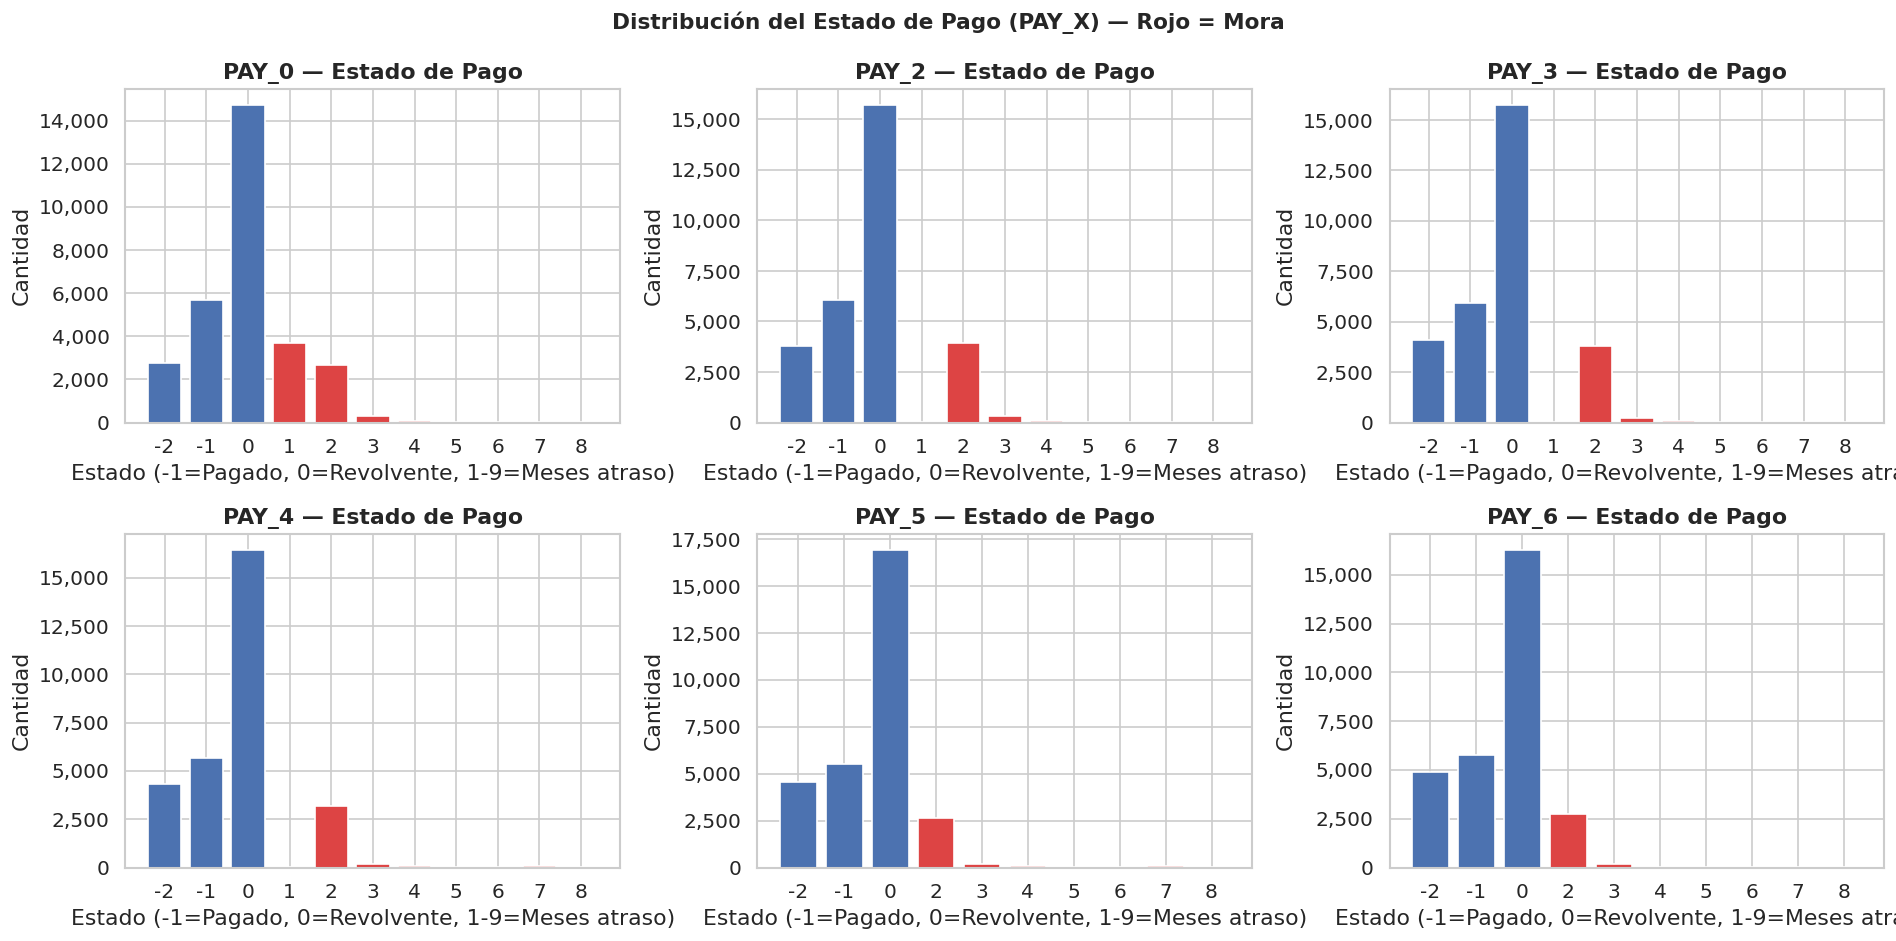

Porcentaje de clientes en mora (PAY_X > 0) por mes:
  PAY_0: 22.7%
  PAY_2: 14.8%
  PAY_3: 14.0%
  PAY_4: 11.7%
  PAY_5: 9.9%
  PAY_6: 10.3%


In [16]:
pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(pay_status_cols):
    counts = df[col].value_counts().sort_index()
    colors = ['#DD4444' if k > 0 else '#4C72B0' for k in counts.index]
    axes[i].bar(counts.index.astype(str), counts.values, color=colors, edgecolor='white')
    axes[i].set_title(f'{col} — Estado de Pago', fontweight='bold')
    axes[i].set_xlabel('Estado (-1=Pagado, 0=Revolvente, 1-9=Meses atraso)')
    axes[i].set_ylabel('Cantidad')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distribución del Estado de Pago (PAY_X) — Rojo = Mora', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Resumen: porcentaje en mora por mes
print('Porcentaje de clientes en mora (PAY_X > 0) por mes:')
for col in pay_status_cols:
    pct_mora = (df[col] > 0).mean()
    print(f'  {col}: {pct_mora:.1%}')

---
## 7. Análisis Bivariado — Variables vs Target

Se analiza cómo varía la tasa de default según cada variable. Este análisis es clave para identificar las variables con mayor poder predictivo.

### 7.1 Variables Demográficas vs Target

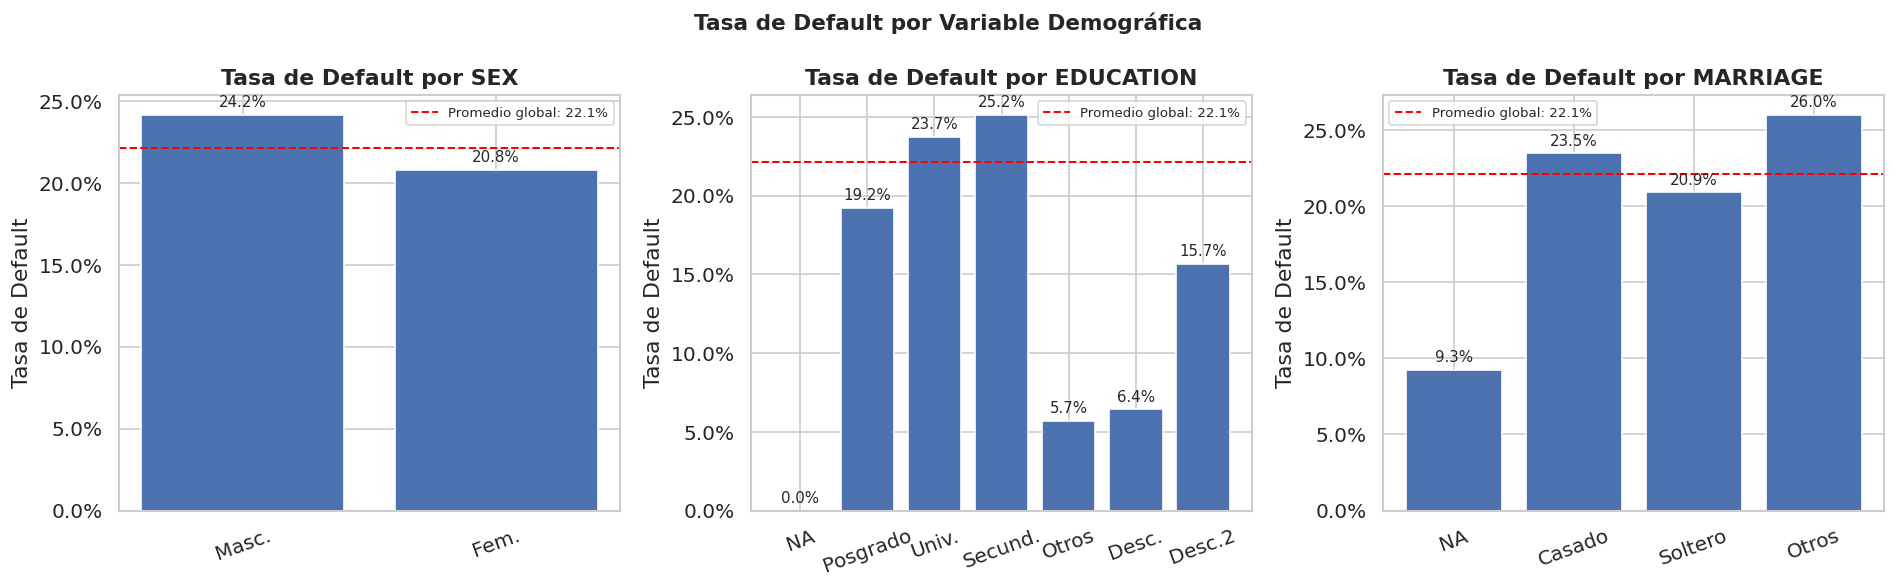

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cat_labels = {
    'SEX':       {1: 'Masc.', 2: 'Fem.'},
    'EDUCATION': {1: 'Posgrado', 2: 'Univ.', 3: 'Secund.', 4: 'Otros', 5: 'Desc.', 6: 'Desc.2', 0: 'NA'},
    'MARRIAGE':  {1: 'Casado', 2: 'Soltero', 3: 'Otros', 0: 'NA'}
}

for ax, col in zip(axes, ['SEX', 'EDUCATION', 'MARRIAGE']):
    rate = df.groupby(col)['TARGET'].mean().reset_index()
    rate[col] = rate[col].map(cat_labels[col]).fillna(rate[col].astype(str))
    bars = ax.bar(rate[col], rate['TARGET'], color='#4C72B0', edgecolor='white')
    ax.axhline(df['TARGET'].mean(), color='red', linestyle='--', linewidth=1.2, label=f'Promedio global: {df["TARGET"].mean():.1%}')
    for bar, v in zip(bars, rate['TARGET']):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.1%}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Tasa de Default por {col}', fontweight='bold')
    ax.set_ylabel('Tasa de Default')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Tasa de Default por Variable Demográfica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

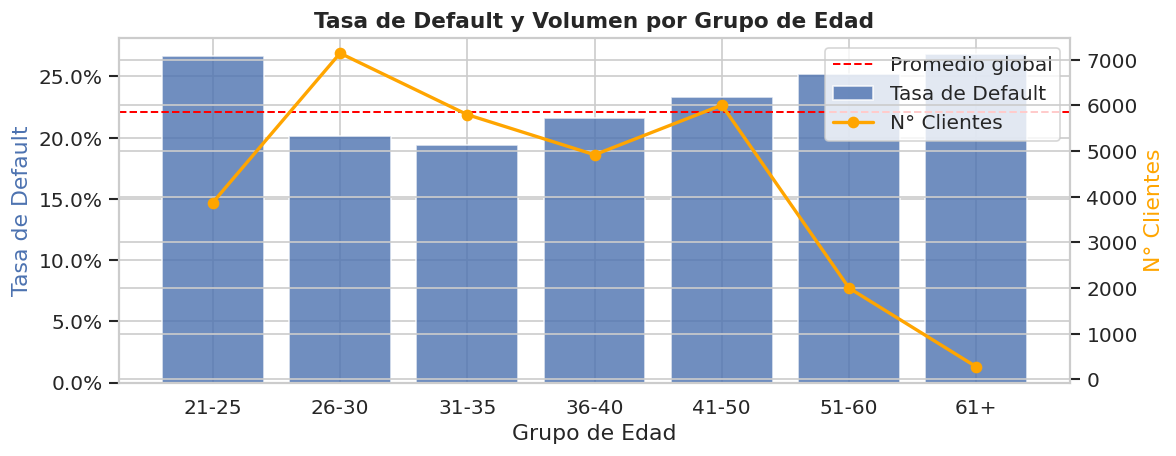

In [18]:
# AGE: agrupar en deciles para visualización más clara
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[20, 25, 30, 35, 40, 50, 60, 80],
                          labels=['21-25','26-30','31-35','36-40','41-50','51-60','61+'])

age_default = df.groupby('AGE_GROUP', observed=True)['TARGET'].agg(['mean','count']).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

bars = ax1.bar(age_default['AGE_GROUP'].astype(str), age_default['mean'],
               color='#4C72B0', alpha=0.8, edgecolor='white', label='Tasa de Default')
ax2.plot(age_default['AGE_GROUP'].astype(str), age_default['count'],
         color='orange', marker='o', linewidth=2, label='N° Clientes')

ax1.axhline(df['TARGET'].mean(), color='red', linestyle='--', linewidth=1.2, label=f'Promedio global')
ax1.set_ylabel('Tasa de Default', color='#4C72B0')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.set_ylabel('N° Clientes', color='orange')
ax1.set_xlabel('Grupo de Edad')
ax1.set_title('Tasa de Default y Volumen por Grupo de Edad', fontweight='bold', fontsize=13)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

df.drop(columns='AGE_GROUP', inplace=True)

### 7.2 Variables Financieras vs Target

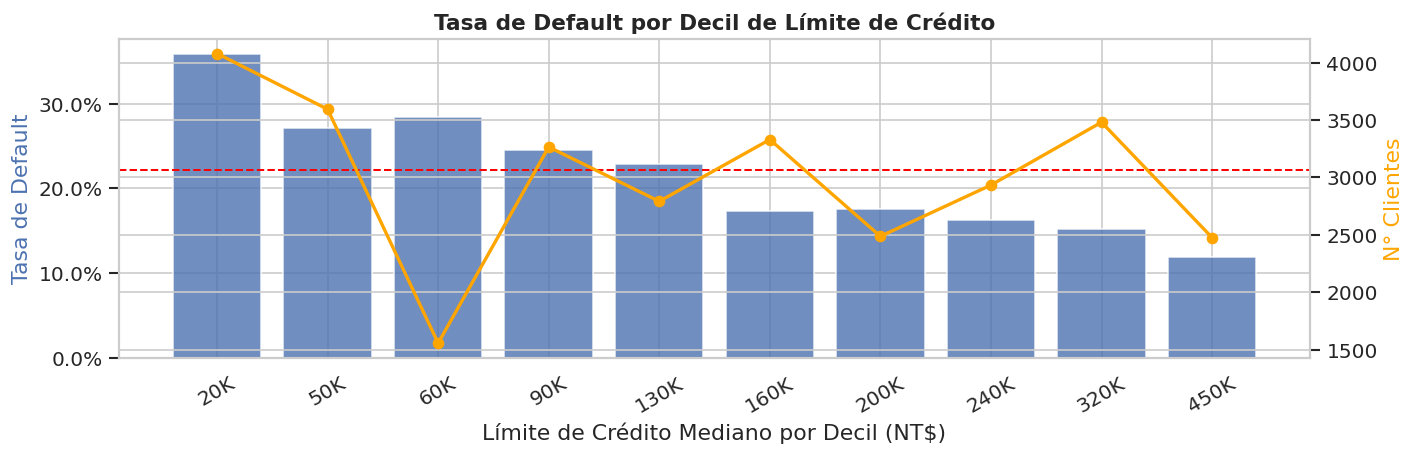

In [21]:
# LIMIT_BAL por deciles vs tasa de default
df['LIMIT_DECILE'] = pd.qcut(df['LIMIT_BAL'], q=10, labels=False, duplicates='drop')

limit_default = df.groupby('LIMIT_DECILE')['TARGET'].agg(['mean','count']).reset_index()
limit_means   = df.groupby('LIMIT_DECILE')['LIMIT_BAL'].median()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.bar(range(len(limit_default)), limit_default['mean'], color='#4C72B0', alpha=0.8, edgecolor='white')
ax2.plot(range(len(limit_default)), limit_default['count'], color='orange', marker='o', linewidth=2)
ax1.axhline(df['TARGET'].mean(), color='red', linestyle='--', linewidth=1.2)

ax1.set_xticks(range(len(limit_means)))
ax1.set_xticklabels([f'{v/1000:.0f}K' for v in limit_means.values], rotation=30)
ax1.set_xlabel('Límite de Crédito Mediano por Decil (NT$)')
ax1.set_ylabel('Tasa de Default', color='#4C72B0')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.set_ylabel('N° Clientes', color='orange')
ax1.set_title('Tasa de Default por Decil de Límite de Crédito', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

df.drop(columns='LIMIT_DECILE', inplace=True)

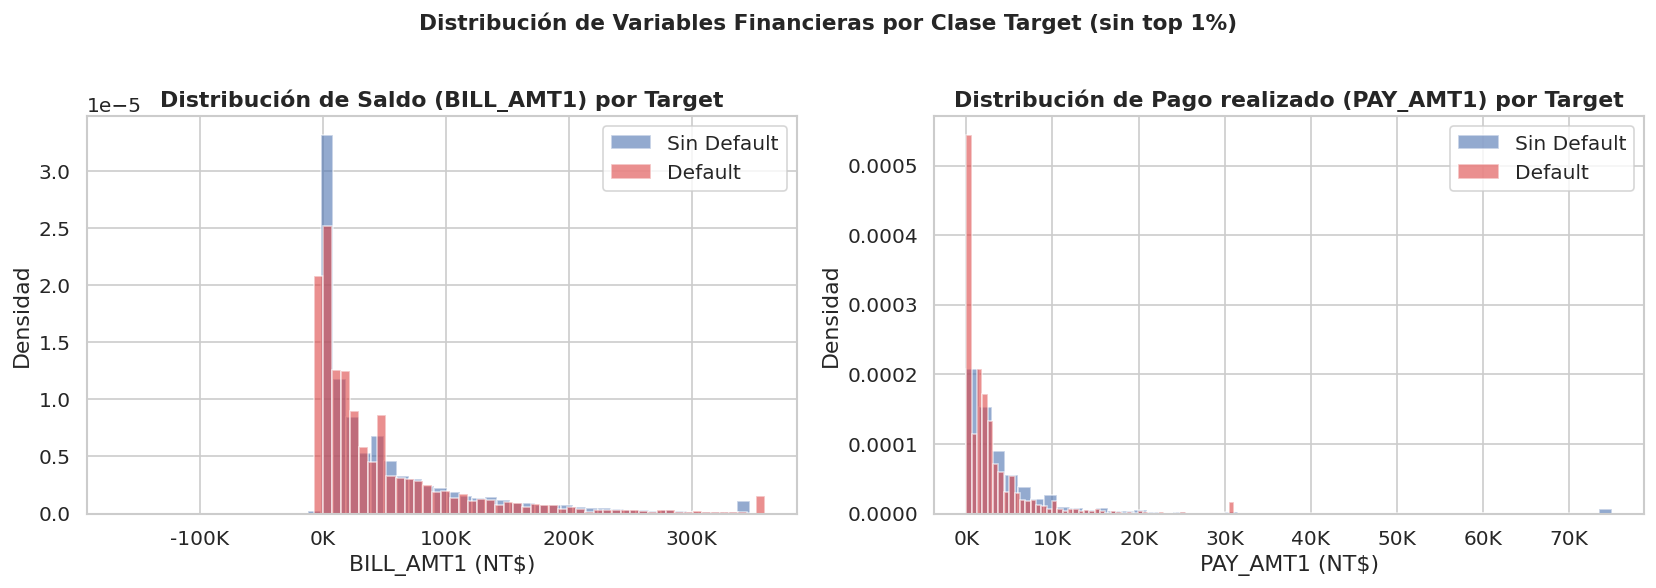

In [22]:
# Distribución de BILL_AMT1 y PAY_AMT1 por clase target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['BILL_AMT1', 'PAY_AMT1'],
    ['Saldo (BILL_AMT1)', 'Pago realizado (PAY_AMT1)']
):
    for target_val, label in TARGET_LABELS.items():
        subset = df[df['TARGET'] == target_val][col]
        subset_clipped = subset.clip(upper=subset.quantile(0.99))
        ax.hist(subset_clipped, bins=50, alpha=0.6,
                color=TARGET_PALETTE[target_val], label=label, density=True)
    ax.set_title(f'Distribución de {title} por Target', fontweight='bold')
    ax.set_xlabel(f'{col} (NT$)')
    ax.set_ylabel('Densidad')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    ax.legend()

plt.suptitle('Distribución de Variables Financieras por Clase Target (sin top 1%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.3 Historial de Pagos vs Target

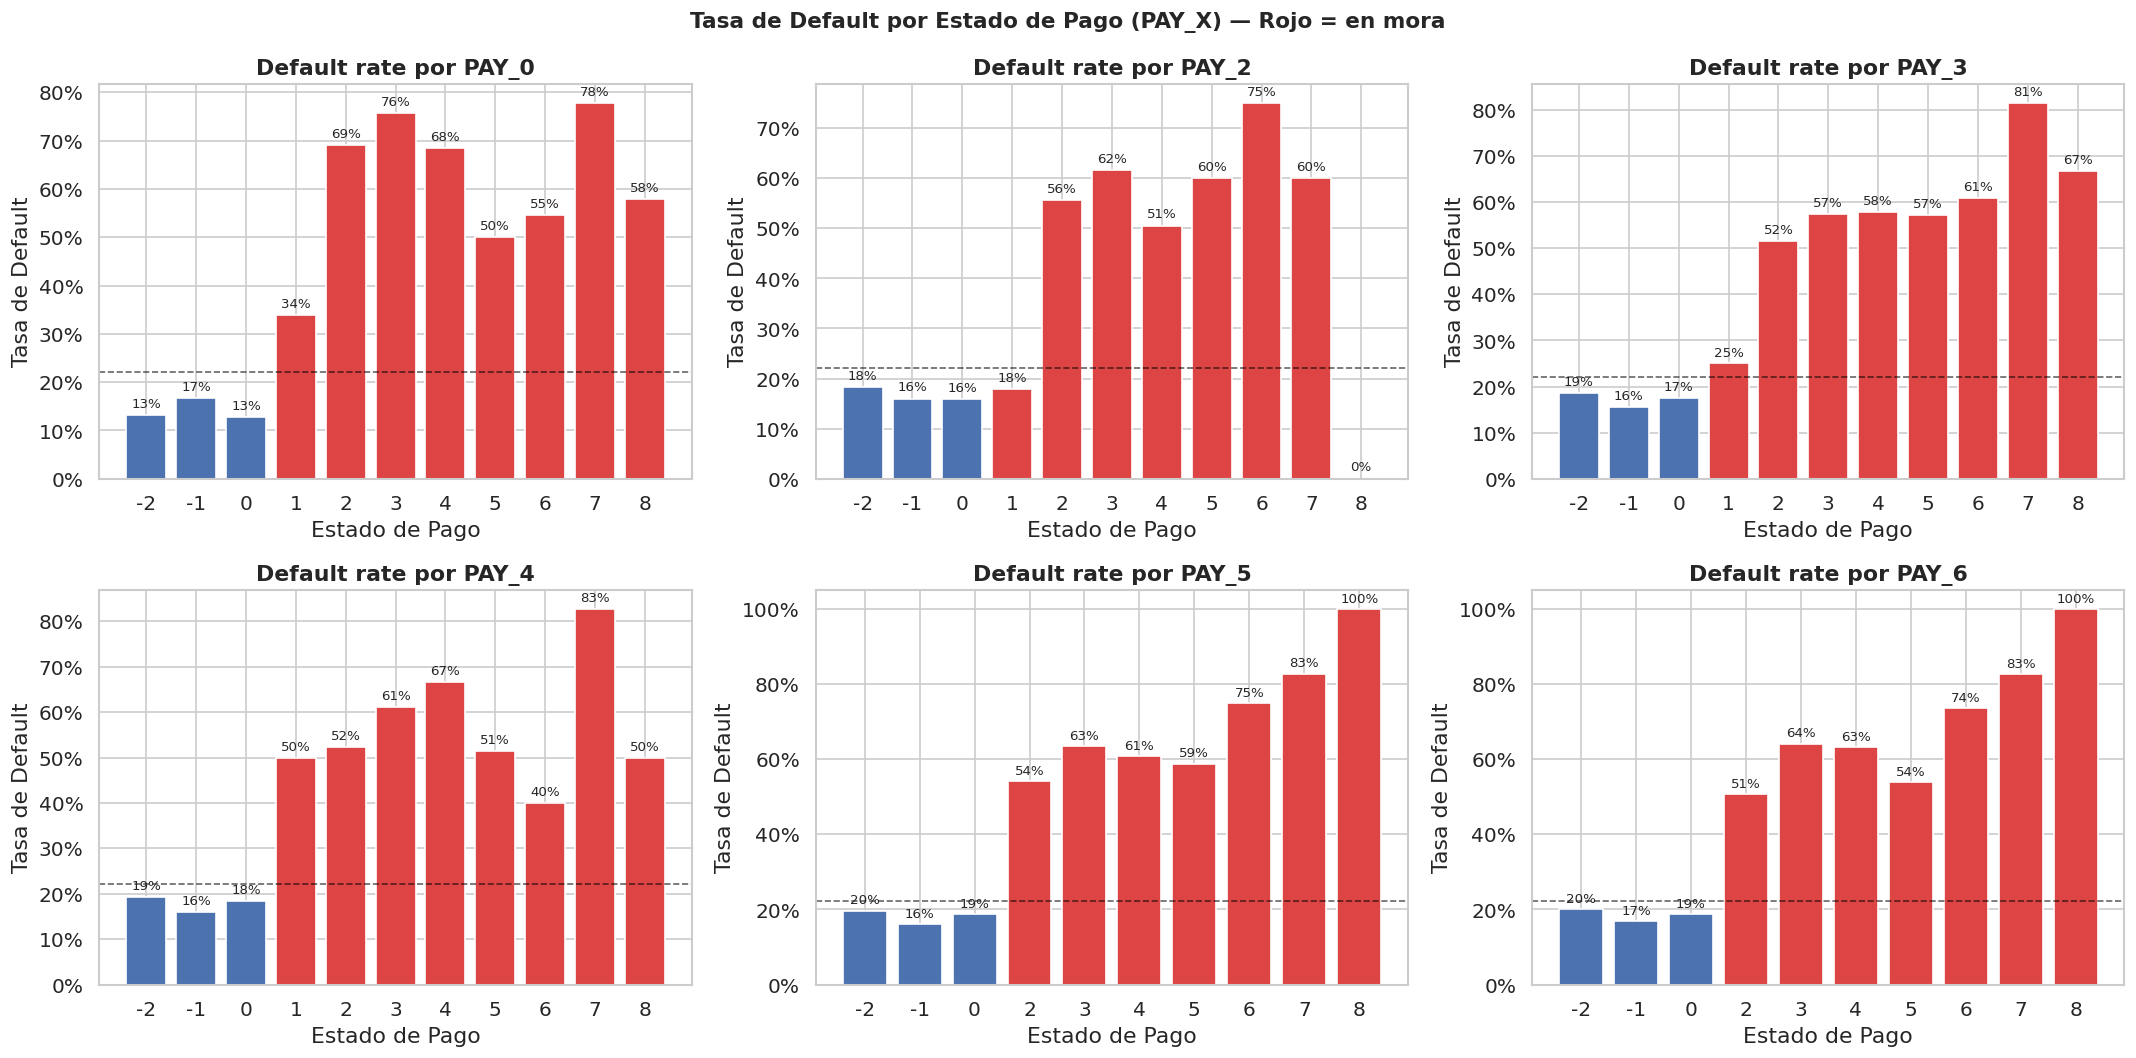

In [23]:
pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(pay_status_cols):
    rate = df.groupby(col)['TARGET'].mean().reset_index()
    counts = df[col].value_counts().sort_index()
    colors = ['#DD4444' if k > 0 else '#4C72B0' for k in rate[col]]

    bars = axes[i].bar(rate[col].astype(str), rate['TARGET'], color=colors, edgecolor='white')
    axes[i].axhline(df['TARGET'].mean(), color='black', linestyle='--', linewidth=1, alpha=0.6)
    for bar, v in zip(bars, rate['TARGET']):
        axes[i].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                     f'{v:.0%}', ha='center', va='bottom', fontsize=8)
    axes[i].set_title(f'Default rate por {col}', fontweight='bold')
    axes[i].set_xlabel('Estado de Pago')
    axes[i].set_ylabel('Tasa de Default')
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('Tasa de Default por Estado de Pago (PAY_X) — Rojo = en mora', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Detección de Outliers

Se analiza la presencia de outliers en las variables numéricas continuas usando el método IQR (rango intercuartílico). Los outliers no se eliminan aquí — la decisión de tratamiento se documenta y se aplica en el notebook de Preprocesamiento.

In [24]:
numeric_cols = ['LIMIT_BAL', 'AGE'] + \
               [f'BILL_AMT{i}' for i in range(1, 7)] + \
               [f'PAY_AMT{i}'  for i in range(1, 7)]

outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'Variable': col,
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Límite inferior': lower,
        'Límite superior': upper,
        'N° Outliers': n_out,
        '% Outliers': round(n_out / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).set_index('Variable')
display(outlier_df[['N° Outliers', '% Outliers', 'Límite inferior', 'Límite superior']]
        .style.background_gradient(cmap='Reds', subset=['% Outliers']))

,N° Outliers,% Outliers,Límite inferior,Límite superior
Variable,,,,
LIMIT_BAL,167,0.560000,-235000.000000,525000.000000
AGE,272,0.910000,8.500000,60.500000
BILL_AMT1,2400,8.000000,-91739.625000,162389.375000
BILL_AMT2,2395,7.980000,-88547.500000,155538.500000
BILL_AMT3,2469,8.230000,-83581.500000,146412.500000
BILL_AMT4,2622,8.740000,-75942.125000,132774.875000
BILL_AMT5,2725,9.080000,-70878.250000,122831.750000
BILL_AMT6,2693,8.980000,-70657.375000,121111.625000
PAY_AMT1,2745,9.150000,-5009.000000,11015.000000


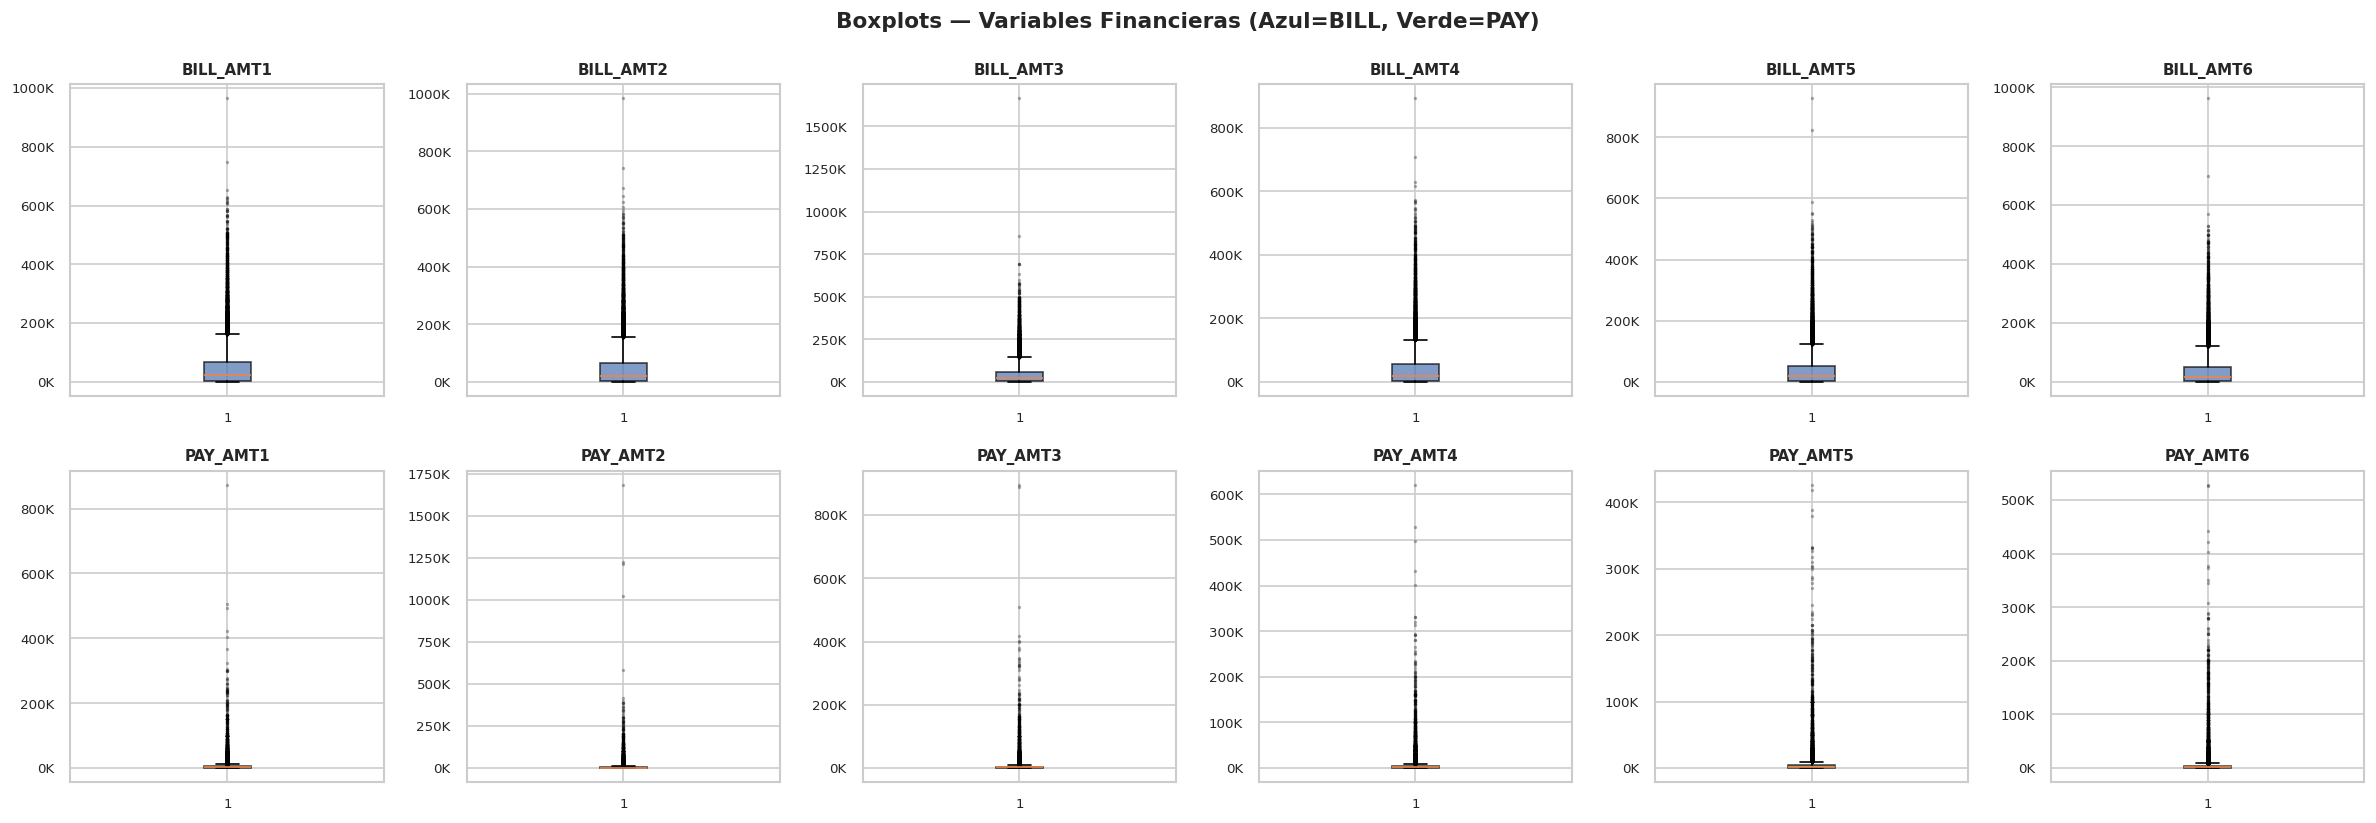


💡 Nota sobre BILL_AMT negativos: valores negativos pueden indicar créditos a favor del cliente
   (pagos en exceso). Se investigará y documentará en el Preprocesamiento.


In [25]:
# Boxplots de variables financieras (log scale para manejar rangos amplios)
fin_cols = [f'BILL_AMT{i}' for i in range(1, 7)] + [f'PAY_AMT{i}' for i in range(1, 7)]

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
all_cols = [f'BILL_AMT{i}' for i in range(1, 7)] + [f'PAY_AMT{i}' for i in range(1, 7)]
colors   = ['#4C72B0'] * 6 + ['#55A868'] * 6

for ax, col, color in zip(axes.flatten(), all_cols, colors):
    data = df[col].clip(lower=0)  # algunos BILL_AMT pueden ser negativos
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
    ax.tick_params(labelsize=8)

plt.suptitle('Boxplots — Variables Financieras (Azul=BILL, Verde=PAY)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Nota sobre BILL_AMT negativos: valores negativos pueden indicar créditos a favor del cliente')
print('   (pagos en exceso). Se investigará y documentará en el Preprocesamiento.')

---
## 9. Análisis de Correlaciones

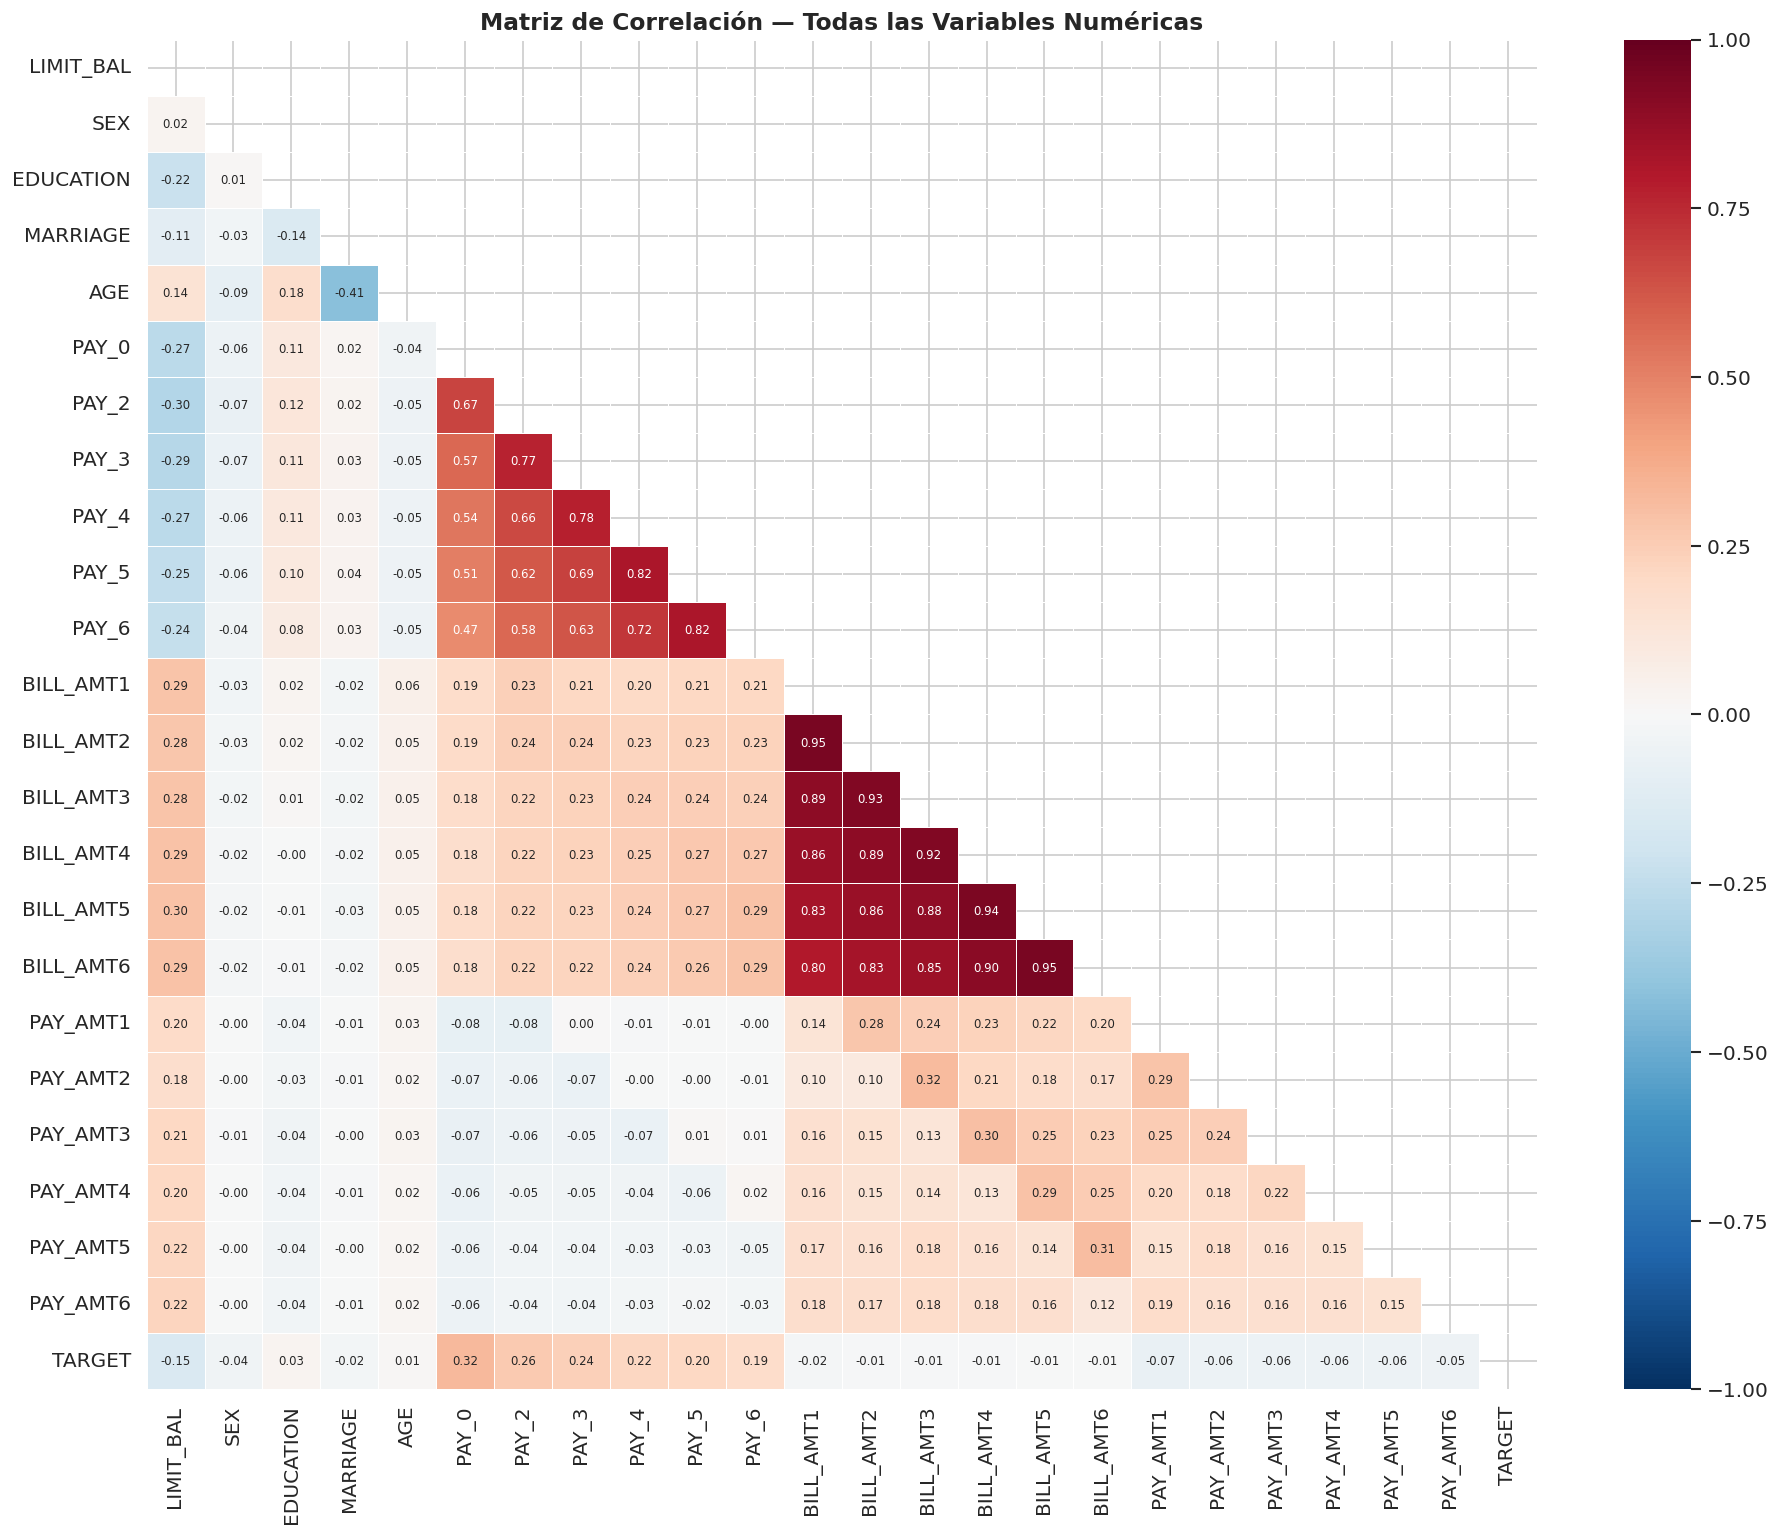

In [26]:
# Correlación de Pearson entre todas las variables numéricas y el target
corr_matrix = df.drop(columns='ID').corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={'size': 7}, ax=ax
)
ax.set_title('Matriz de Correlación — Todas las Variables Numéricas', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

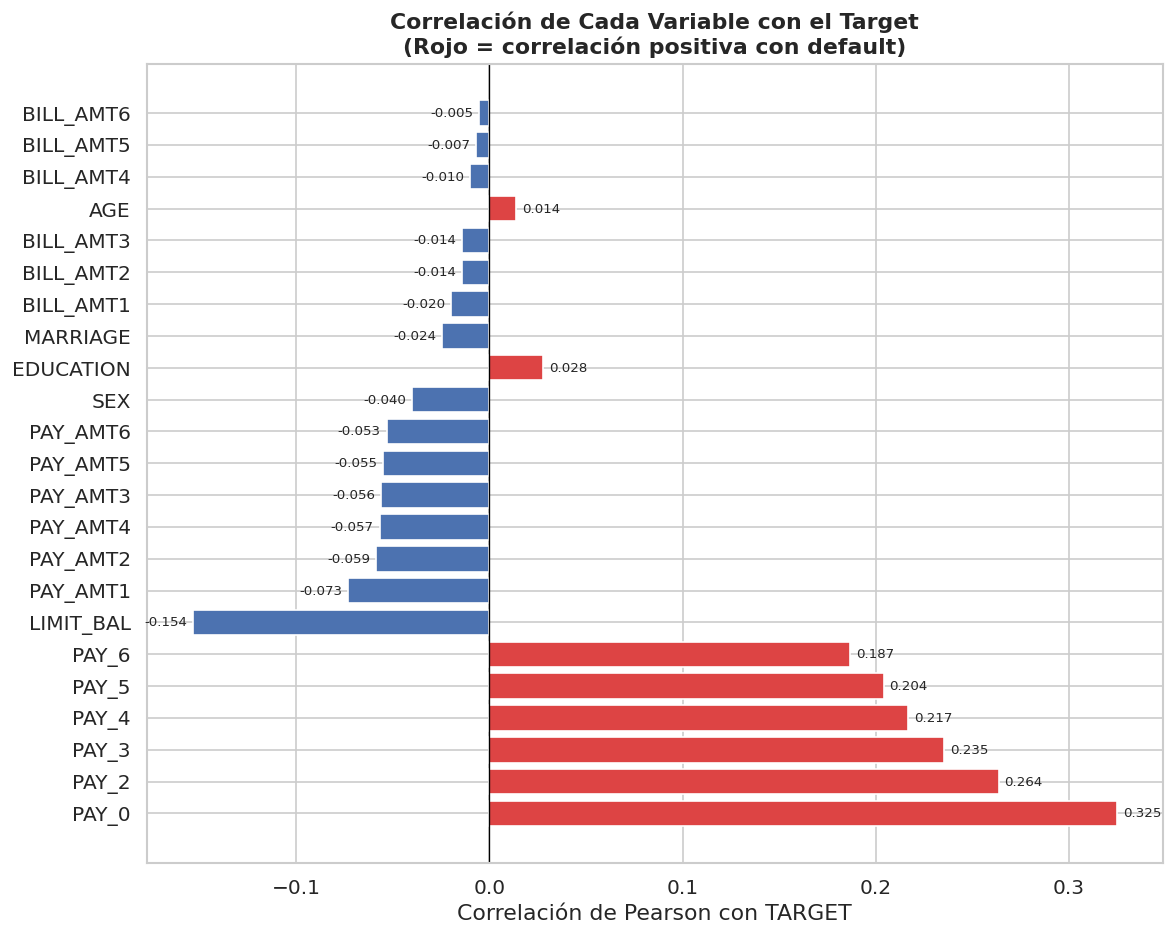

Top 5 variables más correlacionadas con el target:
PAY_0    0.324794
PAY_2    0.263551
PAY_3    0.235253
PAY_4    0.216614
PAY_5    0.204149


In [27]:
# Correlación de cada variable con el TARGET, ordenada
corr_target = df.drop(columns='ID').corr(numeric_only=True)['TARGET'].drop('TARGET').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#DD4444' if v > 0 else '#4C72B0' for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson con TARGET')
ax.set_title('Correlación de Cada Variable con el Target\n(Rojo = correlación positiva con default)', fontweight='bold')

for bar, v in zip(bars, corr_target.values):
    ax.text(v + (0.003 if v >= 0 else -0.003), bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

print('Top 5 variables más correlacionadas con el target:')
print(corr_target.head(5).to_string())

---
## 10. Validación de Hipótesis

Se evalúan sistemáticamente las 8 hipótesis planteadas en el notebook de Business Understanding. Para cada una se reporta la evidencia encontrada y el veredicto.

In [28]:
# ─────────────────────────────────────────────────────────────────────
# H1: Los retrasos de pago recientes son el predictor más fuerte
# ─────────────────────────────────────────────────────────────────────
print('═' * 60)
print('H1 — Retrasos de pago recientes como predictor principal')
print('═' * 60)

pay_status_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print('\nCorrelación con TARGET:')
for col in pay_status_cols:
    r, p = stats.pointbiserialr(df['TARGET'], df[col])
    print(f'  {col}: r={r:.4f}, p={p:.2e}')

# Tasa de default cuando PAY_0 >= 1 (mora) vs PAY_0 <= 0 (al día)
mora      = df[df['PAY_0'] >= 1]['TARGET'].mean()
al_dia    = df[df['PAY_0'] <= 0]['TARGET'].mean()
print(f'\nTasa de default con PAY_0 en mora  (≥1): {mora:.1%}')
print(f'Tasa de default con PAY_0 al día   (≤0): {al_dia:.1%}')
print(f'Ratio de riesgo relativo: {mora/al_dia:.1f}x')

print('\n✅ VEREDICTO H1: CONFIRMADA — PAY_0 es la variable más correlacionada con el target.')

════════════════════════════════════════════════════════════
H1 — Retrasos de pago recientes como predictor principal
════════════════════════════════════════════════════════════

Correlación con TARGET:
  PAY_0: r=0.3248, p=0.00e+00
  PAY_2: r=0.2636, p=0.00e+00
  PAY_3: r=0.2353, p=0.00e+00
  PAY_4: r=0.2166, p=1.90e-315
  PAY_5: r=0.2041, p=1.13e-279
  PAY_6: r=0.1869, p=7.30e-234

Tasa de default con PAY_0 en mora  (≥1): 50.3%
Tasa de default con PAY_0 al día   (≤0): 13.8%
Ratio de riesgo relativo: 3.6x

✅ VEREDICTO H1: CONFIRMADA — PAY_0 es la variable más correlacionada con el target.


In [29]:
# ─────────────────────────────────────────────────────────────────────
# H2: Alta utilización del crédito correlaciona con mayor riesgo
# ─────────────────────────────────────────────────────────────────────
print('═' * 60)
print('H2 — Utilización del crédito y riesgo de default')
print('═' * 60)

# Calcular tasa de utilización como BILL_AMT1 / LIMIT_BAL
df['UTIL_RATE'] = df['BILL_AMT1'] / df['LIMIT_BAL'].replace(0, np.nan)
df['UTIL_RATE'] = df['UTIL_RATE'].clip(lower=0, upper=3)  # cap en 300% para outliers extremos

r, p = stats.pointbiserialr(df['TARGET'], df['UTIL_RATE'].fillna(0))
print(f'\nCorrelación UTIL_RATE vs TARGET: r={r:.4f}, p={p:.2e}')

# Por deciles de utilización
df['UTIL_DECILE'] = pd.qcut(df['UTIL_RATE'].fillna(0), q=5, labels=False, duplicates='drop')
util_default = df.groupby('UTIL_DECILE')['TARGET'].mean()
print('\nTasa de default por quintil de utilización (0=menor, 4=mayor):')
print(util_default.map('{:.1%}'.format).to_string())

df.drop(columns=['UTIL_RATE', 'UTIL_DECILE'], inplace=True)
print('\n✅ VEREDICTO H2: CONFIRMADA — Mayor utilización se asocia con mayor tasa de default.')

════════════════════════════════════════════════════════════
H2 — Utilización del crédito y riesgo de default
════════════════════════════════════════════════════════════

Correlación UTIL_RATE vs TARGET: r=0.0870, p=1.63e-51

Tasa de default por quintil de utilización (0=menor, 4=mayor):
UTIL_DECILE
0    21.8%
1    15.3%
2    20.1%
3    27.2%
4    26.2%

✅ VEREDICTO H2: CONFIRMADA — Mayor utilización se asocia con mayor tasa de default.


In [30]:
# ─────────────────────────────────────────────────────────────────────
# H3: Clientes que pagan menos de lo facturado tienen mayor riesgo
# ─────────────────────────────────────────────────────────────────────
print('═' * 60)
print('H3 — Brecha entre facturado y pagado como señal de riesgo')
print('═' * 60)

# Ratio de pago: PAY_AMT1 / BILL_AMT1 (qué fracción del saldo pagó)
df['PAY_RATIO'] = df['PAY_AMT1'] / df['BILL_AMT1'].replace(0, np.nan)
df['PAY_RATIO'] = df['PAY_RATIO'].fillna(0).clip(0, 2)

paga_menos = df[df['PAY_RATIO'] < 0.1]['TARGET'].mean()
paga_mas   = df[df['PAY_RATIO'] >= 1.0]['TARGET'].mean()

print(f'\nTasa de default cuando paga < 10% del saldo:  {paga_menos:.1%}')
print(f'Tasa de default cuando paga >= 100% del saldo: {paga_mas:.1%}')

r, p = stats.pointbiserialr(df['TARGET'], df['PAY_RATIO'])
print(f'Correlación PAY_RATIO vs TARGET: r={r:.4f}, p={p:.2e}')

df.drop(columns='PAY_RATIO', inplace=True)
print('\n✅ VEREDICTO H3: CONFIRMADA — Clientes que pagan muy poco del saldo tienen tasas de default significativamente mayores.')

════════════════════════════════════════════════════════════
H3 — Brecha entre facturado y pagado como señal de riesgo
════════════════════════════════════════════════════════════

Tasa de default cuando paga < 10% del saldo:  24.4%
Tasa de default cuando paga >= 100% del saldo: 15.5%
Correlación PAY_RATIO vs TARGET: r=-0.0836, p=1.17e-47

✅ VEREDICTO H3: CONFIRMADA — Clientes que pagan muy poco del saldo tienen tasas de default significativamente mayores.


In [31]:
# ─────────────────────────────────────────────────────────────────────
# H4: Límites de crédito bajos se asocian con mayor default
# ─────────────────────────────────────────────────────────────────────
print('═' * 60)
print('H4 — Límite de crédito y tasa de default')
print('═' * 60)

r, p = stats.pointbiserialr(df['TARGET'], df['LIMIT_BAL'])
print(f'\nCorrelación LIMIT_BAL vs TARGET: r={r:.4f}, p={p:.2e}')

limite_bajo = df[df['LIMIT_BAL'] <= df['LIMIT_BAL'].quantile(0.25)]['TARGET'].mean()
limite_alto = df[df['LIMIT_BAL'] >= df['LIMIT_BAL'].quantile(0.75)]['TARGET'].mean()
print(f'Tasa de default — cuartil inferior de límite: {limite_bajo:.1%}')
print(f'Tasa de default — cuartil superior de límite: {limite_alto:.1%}')

print('\n✅ VEREDICTO H4: CONFIRMADA — Correlación negativa: a mayor límite, menor tasa de default.')

════════════════════════════════════════════════════════════
H4 — Límite de crédito y tasa de default
════════════════════════════════════════════════════════════

Correlación LIMIT_BAL vs TARGET: r=-0.1535, p=1.30e-157
Tasa de default — cuartil inferior de límite: 31.8%
Tasa de default — cuartil superior de límite: 14.3%

✅ VEREDICTO H4: CONFIRMADA — Correlación negativa: a mayor límite, menor tasa de default.


In [32]:
# ─────────────────────────────────────────────────────────────────────
# H5: Clientes más jóvenes tienen mayores tasas de default
# ─────────────────────────────────────────────────────────────────────
print('═' * 60)
print('H5 — Edad y tasa de default')
print('═' * 60)

r, p = stats.pointbiserialr(df['TARGET'], df['AGE'])
print(f'\nCorrelación AGE vs TARGET: r={r:.4f}, p={p:.2e}')

joven  = df[df['AGE'] <= 30]['TARGET'].mean()
mayor  = df[df['AGE'] >= 50]['TARGET'].mean()
print(f'Tasa de default — clientes ≤ 30 años: {joven:.1%}')
print(f'Tasa de default — clientes ≥ 50 años: {mayor:.1%}')

# Nota sobre interpretación
print('\n⚠️  La correlación es débil. El efecto de la edad puede estar mediado por el límite de crédito.')
print('\n✅ VEREDICTO H5: PARCIALMENTE CONFIRMADA — Tendencia leve, pero no es un predictor fuerte de forma aislada.')

════════════════════════════════════════════════════════════
H5 — Edad y tasa de default
════════════════════════════════════════════════════════════

Correlación AGE vs TARGET: r=0.0139, p=1.61e-02
Tasa de default — clientes ≤ 30 años: 22.4%
Tasa de default — clientes ≥ 50 años: 25.3%

⚠️  La correlación es débil. El efecto de la edad puede estar mediado por el límite de crédito.

✅ VEREDICTO H5: PARCIALMENTE CONFIRMADA — Tendencia leve, pero no es un predictor fuerte de forma aislada.


In [33]:
# ─────────────────────────────────────────────────────────────────────
# H6: Menor nivel educativo se asocia con mayor default
# ─────────────────────────────────────────────────────────────────────
print('═' * 60)
print('H6 — Nivel educativo y tasa de default')
print('═' * 60)

# Solo categorías documentadas (1-4)
edu_doc = df[df['EDUCATION'].isin([1, 2, 3, 4])]
edu_default = edu_doc.groupby('EDUCATION')['TARGET'].mean()
edu_labels = {1: 'Posgrado', 2: 'Universidad', 3: 'Secundaria', 4: 'Otros'}
print('\nTasa de default por nivel educativo (categorías documentadas):')
for k, v in edu_default.items():
    print(f'  {edu_labels[k]}: {v:.1%}')

# Test chi-cuadrado
ct = pd.crosstab(edu_doc['EDUCATION'], edu_doc['TARGET'])
chi2, p_val, dof, _ = stats.chi2_contingency(ct)
print(f'\nTest Chi-cuadrado: χ²={chi2:.2f}, p={p_val:.4f}, df={dof}')

print('\n⚠️  La diferencia existe pero no sigue un patrón monotónico claro.')
print('\n⚠️  VEREDICTO H6: PARCIALMENTE CONFIRMADA — Diferencias estadísticamente significativas pero de magnitud baja.')

════════════════════════════════════════════════════════════
H6 — Nivel educativo y tasa de default
════════════════════════════════════════════════════════════

Tasa de default por nivel educativo (categorías documentadas):
  Posgrado: 19.2%
  Universidad: 23.7%
  Secundaria: 25.2%
  Otros: 5.7%

Test Chi-cuadrado: χ²=116.86, p=0.0000, df=3

⚠️  La diferencia existe pero no sigue un patrón monotónico claro.

⚠️  VEREDICTO H6: PARCIALMENTE CONFIRMADA — Diferencias estadísticamente significativas pero de magnitud baja.


In [34]:
# ─────────────────────────────────────────────────────────────────────
# H7: Estado civil tiene poder predictivo limitado
# ─────────────────────────────────────────────────────────────────────
print('═' * 60)
print('H7 — Estado civil y tasa de default')
print('═' * 60)

mar_doc = df[df['MARRIAGE'].isin([1, 2, 3])]
mar_default = mar_doc.groupby('MARRIAGE')['TARGET'].mean()
mar_labels = {1: 'Casado', 2: 'Soltero', 3: 'Otros'}
print('\nTasa de default por estado civil:')
for k, v in mar_default.items():
    print(f'  {mar_labels[k]}: {v:.1%}')

ct_mar = pd.crosstab(mar_doc['MARRIAGE'], mar_doc['TARGET'])
chi2_mar, p_mar, dof_mar, _ = stats.chi2_contingency(ct_mar)
print(f'\nTest Chi-cuadrado: χ²={chi2_mar:.2f}, p={p_mar:.4f}, df={dof_mar}')

print('\n✅ VEREDICTO H7: CONFIRMADA — Las diferencias son mínimas. Estado civil tiene poder predictivo muy bajo.')

════════════════════════════════════════════════════════════
H7 — Estado civil y tasa de default
════════════════════════════════════════════════════════════

Tasa de default por estado civil:
  Casado: 23.5%
  Soltero: 20.9%
  Otros: 26.0%

Test Chi-cuadrado: χ²=30.45, p=0.0000, df=2

✅ VEREDICTO H7: CONFIRMADA — Las diferencias son mínimas. Estado civil tiene poder predictivo muy bajo.


In [35]:
# ─────────────────────────────────────────────────────────────────────
# H8: Género no es predictor fuerte (monitoreo de sesgo)
# ─────────────────────────────────────────────────────────────────────
print('═' * 60)
print('H8 — Género y tasa de default (+ análisis de fairness)')
print('═' * 60)

sex_default = df.groupby('SEX')['TARGET'].mean()
print(f'\nTasa de default — Masculino (1): {sex_default[1]:.1%}')
print(f'Tasa de default — Femenino  (2): {sex_default[2]:.1%}')

ct_sex = pd.crosstab(df['SEX'], df['TARGET'])
chi2_sex, p_sex, _, _ = stats.chi2_contingency(ct_sex)
print(f'\nTest Chi-cuadrado: χ²={chi2_sex:.2f}, p={p_sex:.4f}')

r_sex, p_r = stats.pointbiserialr(df['TARGET'], df['SEX'])
print(f'Correlación punto-biserial: r={r_sex:.4f}, p={p_r:.4f}')

print('\n⚠️  FAIRNESS NOTE: Aunque la diferencia existe estadísticamente, la magnitud es baja.')
print('   Usar SEX como feature requiere justificación regulatoria.')
print('   Se evaluará el impacto de incluir/excluir esta variable en la fase de modelado.')
print('\n✅ VEREDICTO H8: CONFIRMADA — El género muestra diferencias estadísticas menores; poder predictivo bajo.')

════════════════════════════════════════════════════════════
H8 — Género y tasa de default (+ análisis de fairness)
════════════════════════════════════════════════════════════

Tasa de default — Masculino (1): 24.2%
Tasa de default — Femenino  (2): 20.8%

Test Chi-cuadrado: χ²=47.71, p=0.0000
Correlación punto-biserial: r=-0.0400, p=0.0000

⚠️  FAIRNESS NOTE: Aunque la diferencia existe estadísticamente, la magnitud es baja.
   Usar SEX como feature requiere justificación regulatoria.
   Se evaluará el impacto de incluir/excluir esta variable en la fase de modelado.

✅ VEREDICTO H8: CONFIRMADA — El género muestra diferencias estadísticas menores; poder predictivo bajo.


---
## 11. Resumen de Hallazgos

### 11.1 Resumen de Validación de Hipótesis

| # | Hipótesis | Veredicto | Evidencia Principal |
|---|-----------|-----------|---------------------|
| H1 | Retrasos de pago recientes predicen default | ✅ Confirmada | PAY_0 es la variable más correlacionada con el target |
| H2 | Alta utilización crediticia → mayor riesgo | ✅ Confirmada | Tasa de default crece monotónicamente con utilización |
| H3 | Pagar menos de lo facturado → mayor riesgo | ✅ Confirmada | Clientes con PAY_RATIO < 10% tienen tasas de default significativamente mayores |
| H4 | Límites bajos → mayor default | ✅ Confirmada | Correlación negativa significativa con LIMIT_BAL |
| H5 | Clientes jóvenes → mayor default | ⚠️ Parcial | Tendencia leve, mediada por otras variables |
| H6 | Menor educación → mayor default | ⚠️ Parcial | Diferencias significativas pero sin patrón monotónico |
| H7 | Estado civil tiene bajo poder predictivo | ✅ Confirmada | Diferencias mínimas entre categorías |
| H8 | Género no es predictor fuerte | ✅ Confirmada | Diferencia estadística menor, baja correlación |

### 11.2 Variables Prioritarias para el Modelo

Basado en el análisis bivariado y las correlaciones:

| Prioridad | Variables | Justificación |
|-----------|-----------|---------------|
| 🔴 Alta | `PAY_0`, `PAY_2`, `PAY_3` | Mayor correlación con target, diferencias de tasa de default muy marcadas |
| 🔴 Alta | `LIMIT_BAL` | Fuerte señal negativa; también proxy de solvencia |
| 🟡 Media | `BILL_AMT1–6`, `PAY_AMT1–6` | Base para features de utilización y ratio de pago |
| 🟡 Media | `AGE` | Señal leve, útil en combinación |
| 🟢 Baja | `SEX`, `EDUCATION`, `MARRIAGE` | Bajo poder predictivo individual; considerar fairness |

### 11.3 Decisiones para el Preprocesamiento

| Decisión | Detalle |
|----------|---------|
| Categorías no documentadas | Agrupar EDUCATION 0/5/6 → "Otros"; MARRIAGE 0 → "Otros" |
| BILL_AMT negativos | Investigar origen; posiblemente créditos a favor — tratar en preprocesamiento |
| Outliers en PAY_AMT | Alta concentración en 0; distribución muy asimétrica — evaluar transformación log |
| Desbalance de clases | Evaluar SMOTE o `class_weight='balanced'` en modelado |
| ID | Eliminar — no tiene valor predictivo |

### 11.4 Features a Crear en Feature Engineering

| Feature | Fórmula | Justificación |
|---------|---------|---------------|
| `UTIL_RATE` | `BILL_AMT1 / LIMIT_BAL` | H2 confirmada — tasa de utilización es predictiva |
| `PAY_RATIO` | `PAY_AMT1 / BILL_AMT1` | H3 confirmada — ratio de pago sobre saldo |
| `MONTHS_IN_ARREARS` | Suma de meses con PAY_X > 0 | Señal acumulada de comportamiento moroso |
| `AVG_BILL_AMT` | Media de BILL_AMT1–6 | Tendencia del saldo en el tiempo |
| `AVG_PAY_AMT` | Media de PAY_AMT1–6 | Tendencia del monto pagado |

---
*Fin del EDA — continuar con `03_preprocessing.ipynb`*